# Examples of neural reparamterization for structural optimization

In [the paper](https://arxiv.org/abs/1909.04240), we run every optimization for 1000 steps and focus on the largest problems. These are pretty slow to run, so to keep this notebook interactive we'll focus on smaller examples trained for fewer steps.

In [1]:
# Copyright 2019 Google LLC.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from IPython import display
from PIL import Image
import seaborn
import matplotlib.pyplot as plt
import xarray
import pandas as pd

from neural_structural_optimization import pipeline_utils
from neural_structural_optimization import problems
from neural_structural_optimization import models
from neural_structural_optimization import topo_api
from neural_structural_optimization import train

/Users/antoniovaragnolo/Desktop/Research/neural-structural-optimization/neural_structural_optimization/autograd_lib.py:35: UserWarning: sksparse.cholmod not installed. Falling back to SciPy/SuperLU, but simulations will be about twice as slow.
  warnings.warn(


In [7]:
def train_all(problem, max_iterations, cnn_kwargs=None):
    args = topo_api.specified_task(problem)
    if cnn_kwargs is None:
        cnn_kwargs = {}

    model = models.PixelModel(args=args)
    ds_mma = train.method_of_moving_asymptotes(model, max_iterations)

    model = models.PixelModel(args=args)
    ds_oc = train.optimality_criteria(model, max_iterations)

    model = models.PixelModel(args=args)
    
    #_ = model(None)   # ensure built
    ds_pix = train.train_lbfgs(model, max_iterations)

    #model = models.CNNModel(args=args, **cnn_kwargs)
    #ds_cnn = train.train_lbfgs(model, max_iterations)

    dims = pd.Index(['mma', 'oc', 'pixel-lbfgs'], name='model')
    #dims = pd.Index(['mma', 'oc'], name='model')
    
    return xarray.concat([ds_mma, ds_oc, ds_pix], dim=dims)

## MBB Beam (Figure 2 from paper)

Note that we tweaked the CNN model slightly original version of the paper, which results in a slightly worse design in this particular case.

See the updated figure in our [latest revision](https://openreview.net/forum?id=Bkec3m3q8B) on OpenReview.net.

In [8]:
problem = problems.mbb_beam(height=20, width=60)
max_iterations = 200

# can't upscale by exactly 8x for a 60x20 design region, so upscale by
# only 4x instead
%time ds = train_all(problem, max_iterations, cnn_kwargs=dict(resizes=(1, 1, 2, 2, 1)))

/Users/antoniovaragnolo/mambaforge/envs/topopt39/lib/python3.9/site-packages/autograd/tracer.py:54: RuntimeWarning: overflow encountered in cosh
  return f_raw(*args, **kwargs)
/Users/antoniovaragnolo/mambaforge/envs/topopt39/lib/python3.9/site-packages/autograd/numpy/numpy_vjps.py:175: RuntimeWarning: overflow encountered in square
  defvjp(anp.tanh, lambda ans, x: lambda g: g / anp.cosh(x) ** 2)


CPU times: user 4.58 s, sys: 263 ms, total: 4.84 s
Wall time: 4.86 s


In [9]:
ds

<xarray.Dataset> Size: 6MB
Dimensions:  (model: 3, step: 204, y: 20, x: 60)
Coordinates:
  * step     (step) int64 2kB 0 1 2 3 4 5 6 7 ... 197 198 199 200 201 202 203
  * model    (model) object 24B 'mma' 'oc' 'pixel-lbfgs'
Dimensions without coordinates: y, x
Data variables:
    loss     (model, step) float64 5kB 1.007e+03 1.006e+03 ... 237.9 237.9
    design   (model, step, y, x) float64 6MB 0.5 0.5 0.5 0.5 ... 1.0 1.0 1.0

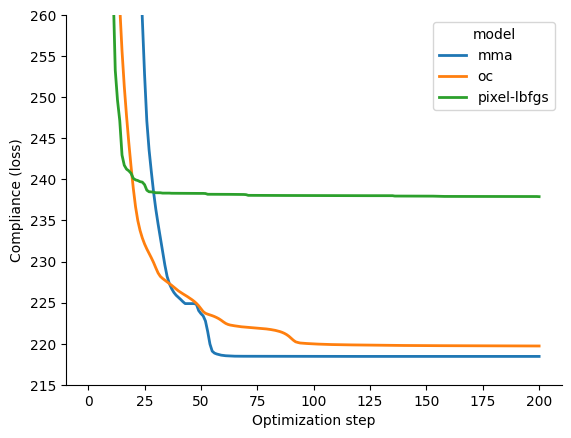

In [10]:
ds.loss.transpose().to_pandas().cummin().loc[:200].plot(linewidth=2)
plt.ylim(215, 260)
plt.ylabel('Compliance (loss)')
plt.xlabel('Optimization step')
seaborn.despine()

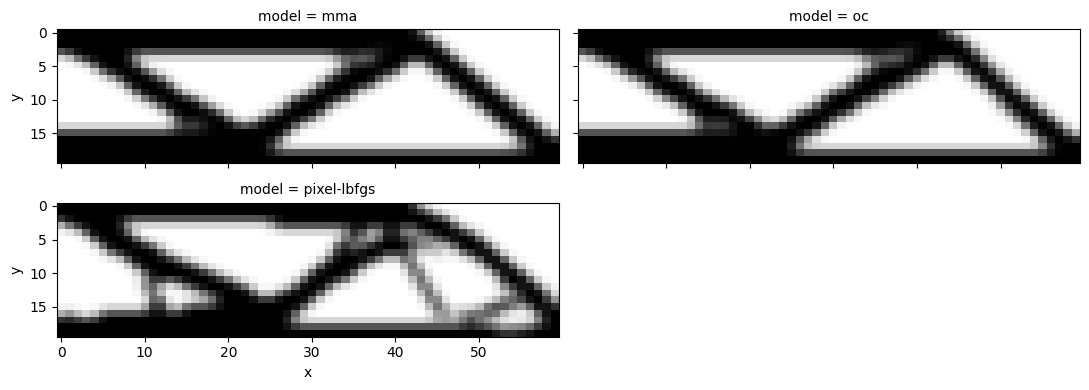

In [11]:
ds.design.sel(step=200).plot.imshow(
    col='model', x='x', y='y', size=2, aspect=2.5, col_wrap=2,
    yincrease=False, add_colorbar=False, cmap='Greys')

If desired, designs can also be converted into `PIL.Image` objects with the `pipeline_utils.image_from_design` utility. This is convenient for exporting single frames or creating GIFs:

In [12]:
def save_gif_movie(images, path, duration=200, loop=0, **kwargs):
    images[0].save(path, save_all=True, append_images=images[1:],
                   duration=duration, loop=loop, **kwargs)

In [14]:
images = [
    pipeline_utils.image_from_design(design, problem)
    for design in ds.design.sel(model='pixel-lbfgs')[:100]
]

In [16]:
save_gif_movie([im.resize((5*120, 5*20)) for im in images], 'movie.gif')

This produces the following movie of the optimization process:

<img src="https://github.com/google-research/neural-structural-optimization/raw/master/notebooks/movie.gif" />

## MBB beam with a larger grid

In [17]:
problem = problems.PROBLEMS_BY_NAME['mbb_beam_192x64_0.4']
max_iterations = 100
%time ds = train_all(problem, max_iterations)

/Users/antoniovaragnolo/mambaforge/envs/topopt39/lib/python3.9/site-packages/autograd/numpy/numpy_vjps.py:175: RuntimeWarning: overflow encountered in square
  defvjp(anp.tanh, lambda ans, x: lambda g: g / anp.cosh(x) ** 2)
/Users/antoniovaragnolo/mambaforge/envs/topopt39/lib/python3.9/site-packages/autograd/tracer.py:54: RuntimeWarning: overflow encountered in cosh
  return f_raw(*args, **kwargs)


CPU times: user 2min 1s, sys: 3min 7s, total: 5min 9s
Wall time: 1min 14s


Now, the CNN-LBFGS model performs best:

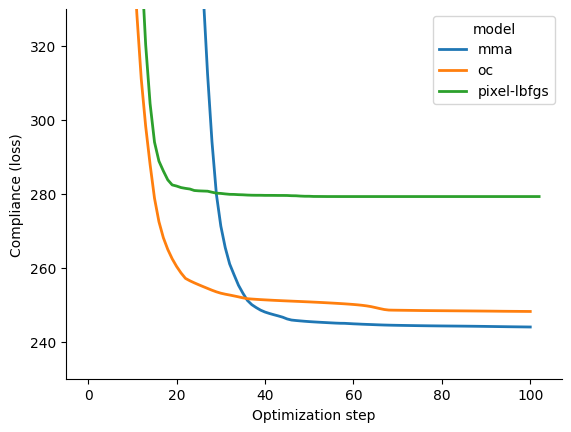

In [18]:
ds.loss.transpose().to_pandas().cummin().loc[:200].plot(linewidth=2)
plt.ylim(230, 330)
plt.ylabel('Compliance (loss)')
plt.xlabel('Optimization step')
seaborn.despine()

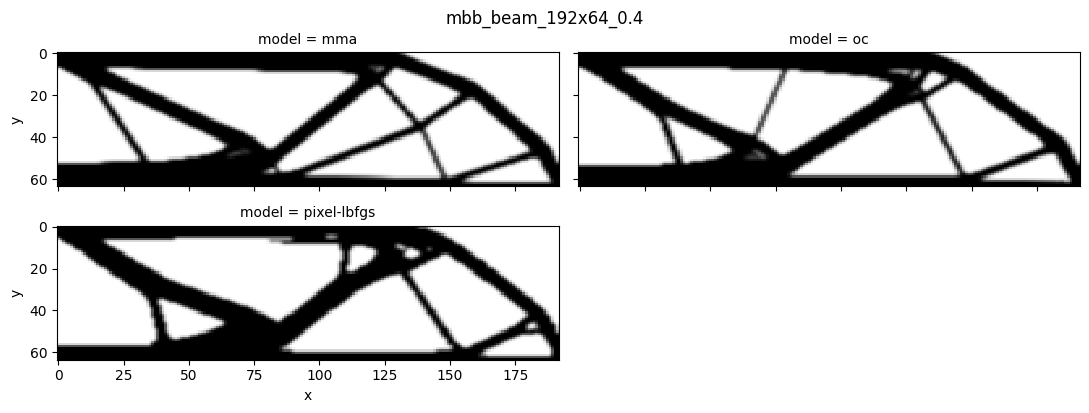

In [20]:
# the pixel-lbfgs does not run for the full 100 steps (it terminates
# early due to reaching a local minima), so use fill() to forward fill
# to the last valid design.
ds.design.ffill('step').sel(step=100).plot.imshow(
    col='model', x='x', y='y', size=2, aspect=2.5, col_wrap=2,
    yincrease=False, add_colorbar=False, cmap='Greys')
plt.suptitle(problem.name, y=1.02);

## Multistory building

In [21]:
problem = problems.PROBLEMS_BY_NAME['multistory_building_64x128_0.4']
max_iterations = 100  # keep things fast
%time ds = train_all(problem, max_iterations)

CPU times: user 33.1 s, sys: 1.95 s, total: 35 s
Wall time: 35.1 s


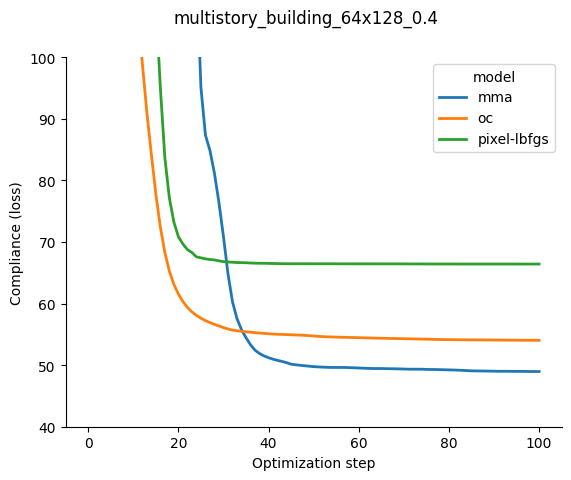

In [24]:
ds.loss.transpose().to_pandas().cummin().loc[:100].plot(linewidth=2)
plt.ylim(40, 100)
plt.ylabel('Compliance (loss)')
plt.xlabel('Optimization step')
seaborn.despine()
plt.suptitle(problem.name);

For fun, we'll examine designs at different time-steps.

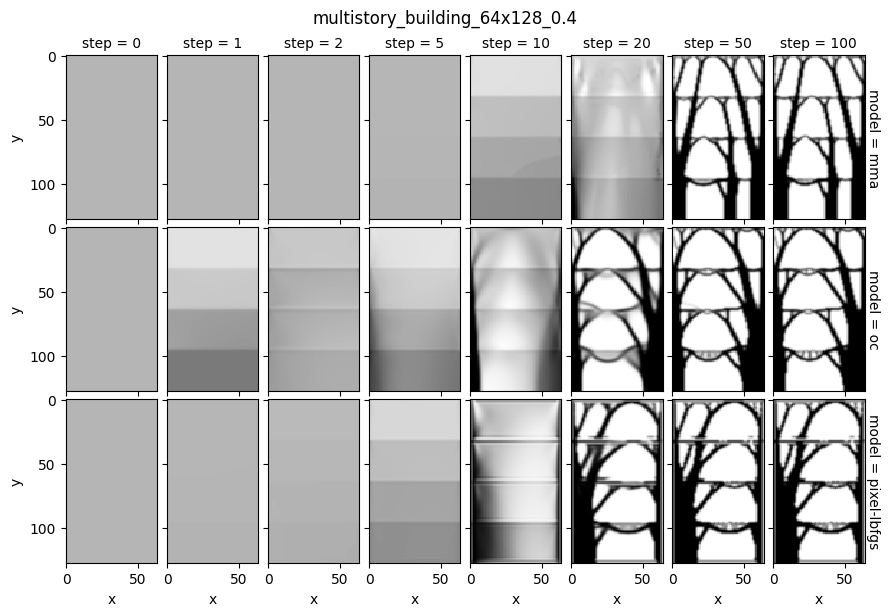

In [25]:
ds.design.sel(step=[0, 1, 2, 5, 10, 20, 50, 100]).plot.imshow(
    row='model', col='step', x='x', y='y', size=2, aspect=0.5,
    yincrease=False, add_colorbar=False, cmap='Greys')
plt.subplots_adjust(wspace=0.1, hspace=0.05)
plt.suptitle(problem.name, y=1.02);

## Thin support bridge

In [17]:
# we really need more iterations to see the CNN-LBFGS method dominate
problem = problems.PROBLEMS_BY_NAME['thin_support_bridge_128x128_0.2']
max_iterations = 200
%time ds = train_all(problem, max_iterations)

/usr/local/lib/python3.6/dist-packages/neural_structural_optimization/autograd_lib.py:102: RuntimeWarning: divide by zero encountered in true_divide
  weights = 1 / raw_filters.sum(axis=0).squeeze()


CPU times: user 26min 12s, sys: 12min 43s, total: 38min 55s
Wall time: 21min 39s


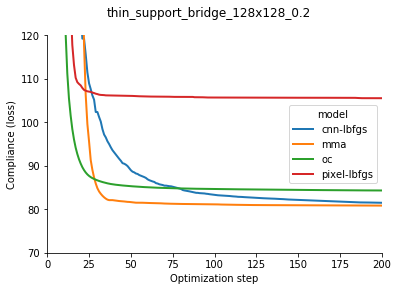

In [18]:
ds.loss.transpose().to_pandas().cummin().plot(linewidth=2)
plt.ylim(70, 120)
plt.ylabel('Compliance (loss)')
plt.xlabel('Optimization step')
seaborn.despine()
plt.suptitle(problem.name);

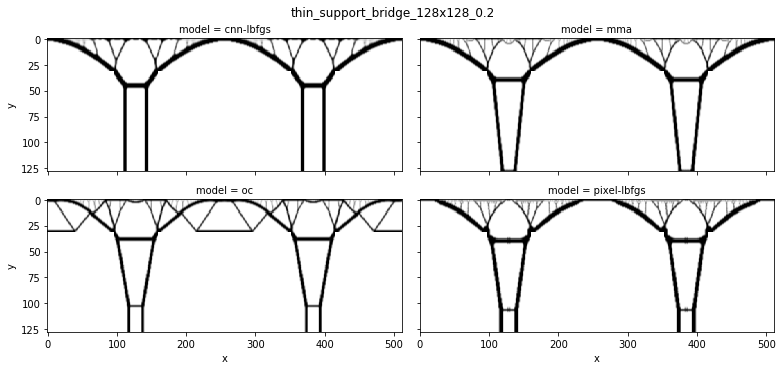

In [19]:
(xarray.concat([ds.design, ds.design.sel(x=slice(None, None, -1))] * 2, dim='x')
 .sel(step=200)
 .plot.imshow(
    col='model', x='x', y='y', size=2.5, aspect=2, col_wrap=2,
    yincrease=False, add_colorbar=False, cmap='Greys'))
plt.suptitle(problem.name, y=1.02);